# Linear Regression

Linear regression is a machine learning technique that is used to fing the best fit line and helps in predicting the continuous numerical varaible

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ins_ds=pd.read_csv("/content/insurance.csv")
ins_ds

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [ ]:
ins_ds.shape

(1338, 13)

The output revealed we have 1338 customers/patients across 13 features in the dataset

In [ ]:
ins_ds.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.21,0.0,0,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,2,1121.8739
1,18.0,1,30.14,0.0,0,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,2,1131.5066
2,18.0,1,33.33,0.0,0,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,2,1135.9407
3,18.0,1,33.66,0.0,0,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,2,1136.3994
4,18.0,1,34.10,0.0,0,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,2,1137.0110


In [ ]:
ins_ds.sample()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
557,43.0,0,34.58,1.0,0,43176.57114,5.0,885104.0,2649409.704,1.0,113730990.0,1,7727.2532


In [ ]:
ins_ds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   int64  
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   int64  
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   int64  
 12  charges             

Now one more thing we need to see is that in children whether its how many children person has or does the person has nay children??? so to do that we will find out it why knowing what kind of values the particular column is holding by using 'value.counts()'

In [ ]:
ins_ds['children'].value_counts()

,count
children,
0.0,574
1.0,321
2.0,240
3.0,156
4.0,25
5.0,17


So,we can clearly interpret that its no of children person is having rather than whether they have children or not

In [ ]:
ins_ds['smoker'].value_counts()

,count
smoker,
0,1064
1,274


In [ ]:

ins_ds['sex'].value_counts()

,count
sex,
1,676
0,662


In [ ]:
ins_ds['region'].value_counts()

,count
region,
2,364
3,325
1,325
0,324


In [ ]:
ins_ds['age'].value_counts()

,count
age,
18.0,69
19.0,66
51.0,29
47.0,29
48.0,29
45.0,29
46.0,29
52.0,29
50.0,29


# DATA CLEANING:

>


NULL VALUES
DUPLICATE VALUES
OUTLEIRS
DATA TYPES

Check forif any NULL VALUES OR not

In [ ]:
ins_ds.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2
region,0


Since,the null values are smallin number so we can simply drop them!!!!

In [ ]:
ins_ds.dropna(inplace=True)

Now (inplace=True) here makes sure that your changes are saved to the original dataset.
nowwe gotta check if this worked and dropped null values or not?

In [ ]:
ins_ds.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0
region,0


Now in some cases the columns might be too much or too large in number to check with above method so we just use the add one more sum!! like shown below

In [ ]:
ins_ds.isnull().sum().sum()

np.int64(0)

This above output shows that there are zero null values in the entire datset!!

Checking for duplicated Values

In [ ]:
ins_ds.duplicated().sum()

np.int64(0)

Output show no duplicated values

Checking for OUTLIERS:
Extremely big or small values different from all the central range of our data.WE can check them using **box plots** and to remove them we use InterQuartile Method(IQR)

Now we only have to look for the fetures'outliers whose data type is numerical type but not object like smoke region gender

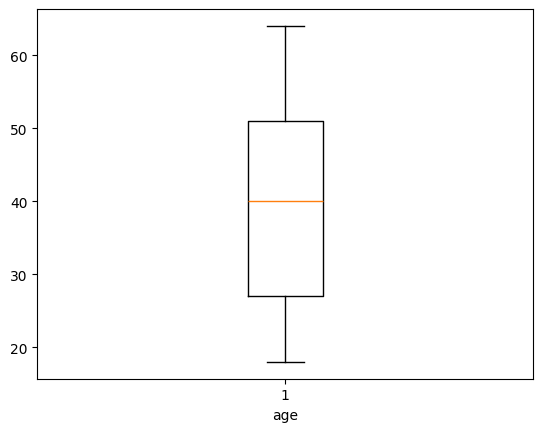

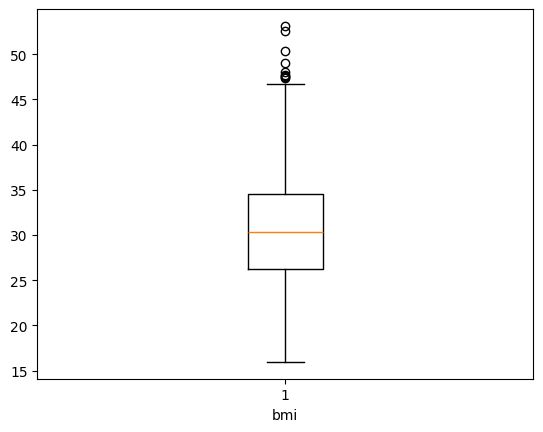

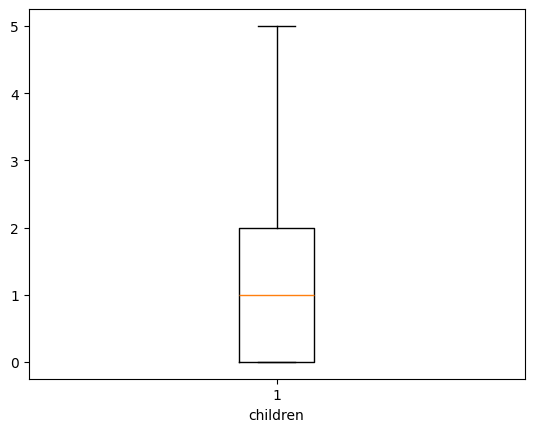

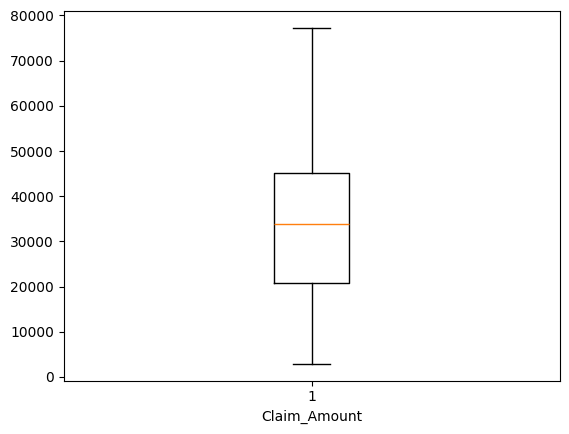

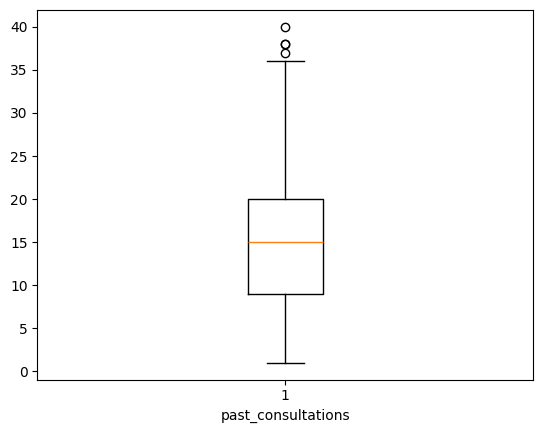

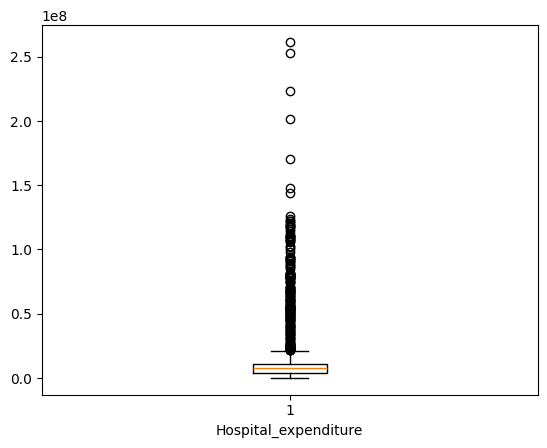

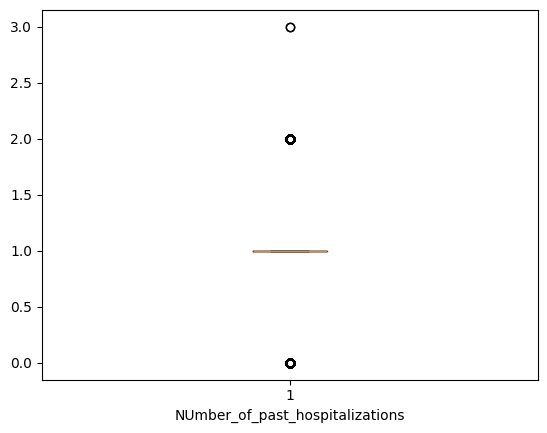

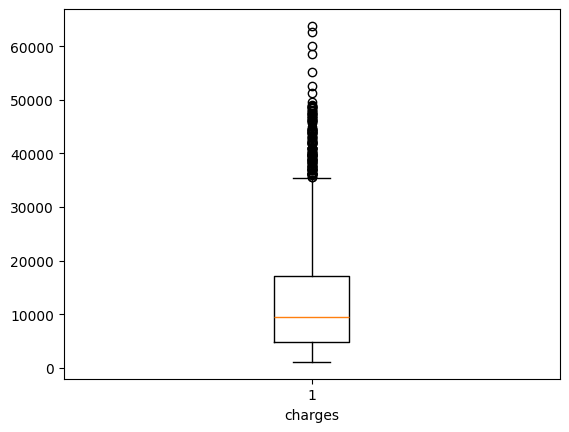

In [ ]:
for col in ins_ds:
  if ins_ds[col].dtype=='float64':
   plt.boxplot(ins_ds[col])
   plt.xlabel(col)
   plt.show()

Now not all outliers have to be fixed it really dpendn how true the values and how they affect the domain values!!!

If there is multicollinearity in data linear regression model will not work well


---So basically multicollinearity is where independent columns are correlated

eg:

monthly salary-50k

annual salary-6lpa

both are basically same and if we consider both we get inaccurate results!!

**Collinearity** on other hand refers to the fact that how dependent value(target) is dependent on the independent value or columns!!

Now if we want to get rid of multicollinearity we need to aaply for **VIF-Variance Inflation Factotr ** but since it only takes numerical type value we nedd to encode the object data type.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

Now here the labelling will be done on the basis of alphabetical order for eg if we have:

India:   0
Spain:   2
Mexico:  1

Since I in India comes first followed by M in Mexico and S in Spain

In [ ]:
ins_ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1296 non-null   float64
 1   sex                              1296 non-null   object 
 2   bmi                              1296 non-null   float64
 3   children                         1296 non-null   float64
 4   smoker                           1296 non-null   object 
 5   Claim_Amount                     1296 non-null   float64
 6   past_consultations               1296 non-null   float64
 7   Hospital_expenditure             1296 non-null   float64
 8   NUmber_of_past_hospitalizations  1296 non-null   float64
 9   region                           1296 non-null   object 
 10  charges                          1296 non-null   float64
dtypes: float64(8), object(3)
memory usage: 121.5+ KB


In [ ]:
for i in ins_ds:
  if ins_ds[i].dtype=='object':
    ins_ds[i]=le.fit_transform(ins_ds[i])


In [ ]:
ins_ds.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0
region,0


In [ ]:
ins_ds.info()
# ALL objecr VALUES WILL BE CONVERTED TO INT64

<class 'pandas.core.frame.DataFrame'>
Index: 1296 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1296 non-null   float64
 1   sex                              1296 non-null   int64  
 2   bmi                              1296 non-null   float64
 3   children                         1296 non-null   float64
 4   smoker                           1296 non-null   int64  
 5   Claim_Amount                     1296 non-null   float64
 6   past_consultations               1296 non-null   float64
 7   Hospital_expenditure             1296 non-null   float64
 8   NUmber_of_past_hospitalizations  1296 non-null   float64
 9   region                           1296 non-null   int64  
 10  charges                          1296 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 121.5 KB


**VIF**---->Variation Inflation Factor

Hepls to measure the multicollinearity scores!!!

the greater the score more it is to be removed and since target variable has mothing to do with collinearity it is to be removed or dropped

In [ ]:
X = ins_ds.drop('charges', axis=1)
X

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,NUmber_of_past_hospitalizations,region
0,18.0,1,0.0,0,29087.54313,17.0,4.720921e+06,0.0,2
1,18.0,1,0.0,0,39053.67437,7.0,4.329832e+06,0.0,2
2,18.0,1,0.0,0,39023.62759,19.0,6.884861e+06,0.0,2
3,18.0,1,0.0,0,28185.39332,11.0,4.274774e+06,0.0,2
4,18.0,1,0.0,0,14697.85941,16.0,3.787294e+06,0.0,2
...,...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,1.703805e+08,2.0,1
1334,31.0,0,1.0,1,43419.95227,31.0,2.015152e+08,2.0,0
1335,52.0,1,3.0,1,52458.92353,25.0,2.236450e+08,2.0,1
1336,45.0,1,0.0,1,69927.51664,34.0,2.528924e+08,3.0,2


In [ ]:
#Importing VIF from stats model

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
Vif_data=pd.DataFrame()#-------->Making a new DataFrame for vif_data

In [ ]:
Vif_data['features']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]

In [ ]:
print(Vif_data)

                           features  Vif_values
0                               age   13.710629
1                               sex    2.009831
2                               bmi   30.159136
3                          children    1.972347
4                            smoker    4.073851
5                      Claim_Amount    6.952488
6                past_consultations    8.593570
7                      num_of_steps   71.160415
8              Hospital_expenditure   30.397183
9   NUmber_of_past_hospitalizations   17.904578
10                     Anual_Salary   48.618196
11                           region    2.933951


Now at a time we can only remove one max vif score ata time as dependecy on indepndent features can affect after one feature is removed

In [ ]:
# ins_ds=ins_ds.drop( ['num_of_steps'],axis=1)

In [ ]:
X = ins_ds.drop('charges', axis=1)
Vif_data=pd.DataFrame()
Vif_data['features']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(Vif_data)

                          features  Vif_values
0                              age   10.700996
1                              sex    1.988949
2                              bmi   13.648168
3                         children    1.933638
4                           smoker    2.890975
5                     Claim_Amount    6.458990
6               past_consultations    7.787513
7             Hospital_expenditure    2.968484
8  NUmber_of_past_hospitalizations   12.906315
9                           region    2.922799


In [ ]:
ins_ds= ins_ds.drop( ['Anual_Salary'],axis=1)

In [ ]:
X = ins_ds.drop('charges', axis=1)
Vif_data=pd.DataFrame()
Vif_data['features']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(Vif_data)


                          features  Vif_values
0                              age   10.700996
1                              sex    1.988949
2                              bmi   13.648168
3                         children    1.933638
4                           smoker    2.890975
5                     Claim_Amount    6.458990
6               past_consultations    7.787513
7             Hospital_expenditure    2.968484
8  NUmber_of_past_hospitalizations   12.906315
9                           region    2.922799


In [ ]:
ins_ds=ins_ds.drop(['bmi'],axis=1)

In [ ]:
X = ins_ds.drop('charges', axis=1)
Vif_data=pd.DataFrame()
Vif_data['features']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(Vif_data)


                          features  Vif_values
0                              age    9.394387
1                              sex    1.895752
2                         children    1.925215
3                           smoker    2.783529
4                     Claim_Amount    5.849267
5               past_consultations    7.176357
6             Hospital_expenditure    2.966158
7  NUmber_of_past_hospitalizations   12.712711
8                           region    2.585903


In [ ]:
ins_ds=ins_ds.drop(['NUmber_of_past_hospitalizations'],axis=1)

In [ ]:
X = ins_ds.drop('charges', axis=1)
Vif_data=pd.DataFrame()
Vif_data['features']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(Vif_data)


               features  Vif_values
0                   age    6.669300
1                   sex    1.893070
2              children    1.799757
3                smoker    2.495596
4          Claim_Amount    5.595156
5    past_consultations    6.939573
6  Hospital_expenditure    2.653015
7                region    2.584898


Now these all values are ok and not need to be removed until they are not above 10

# MODEL BUILDING

In [ ]:
X=ins_ds.drop(['charges'],axis=1)
y=ins_ds['charges']

In [ ]:
X

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
0,18.0,1,0.0,0,29087.54313,17.0,4.720921e+06,2
1,18.0,1,0.0,0,39053.67437,7.0,4.329832e+06,2
2,18.0,1,0.0,0,39023.62759,19.0,6.884861e+06,2
3,18.0,1,0.0,0,28185.39332,11.0,4.274774e+06,2
4,18.0,1,0.0,0,14697.85941,16.0,3.787294e+06,2
...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,1.703805e+08,1
1334,31.0,0,1.0,1,43419.95227,31.0,2.015152e+08,0
1335,52.0,1,3.0,1,52458.92353,25.0,2.236450e+08,1
1336,45.0,1,0.0,1,69927.51664,34.0,2.528924e+08,2


In [ ]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1333,55135.40209
1334,58571.07448
1335,60021.39897
1336,62592.87309


Now after separating dependent and indepoendent columns next task is to split data into train and test can be 80:20,70:30 etc!!

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1) #test size-0.2 means that test size is 20

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [ ]:
#Training the model
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
#Testing the model
y_pred=model.predict(X_test)

In [ ]:
y_pred

array([19202.96275225, 10791.92057997,  2920.53806471, 10843.70412744,
       12111.616053  ,  7996.98815952,  1740.2338426 ,  4233.10553921,
        9157.17148725,  4623.64140783, 19563.72986371, 11971.1445434 ,
       12285.86998335, 33256.02039027,  3466.98113392,  9806.05715636,
        7484.81864611, 12191.98063509,  6958.08808514,  8031.09814915,
        5316.53474033,  9708.66033295,  3799.61794721, 16537.9238771 ,
        6890.01143666,  6976.80371248,  9443.76751055, 13787.98623162,
       14058.0646289 ,  7114.08605526, 33212.10838493, 10288.20260027,
       20468.20933812,  7467.63449535,  3506.1944169 ,  8189.88008384,
       38761.62307414,  8468.30803031, 11996.38696241, 14293.48278159,
        7548.39579908, 19279.96288207, 12490.63633389,  6302.18779903,
        3418.8580691 ,  8244.07440342, 12586.7396472 ,  3150.00002024,
       32829.54832343, 11344.94523236,  3786.02779603,  5485.83988438,
        9390.61645642,  8025.90898662, 11063.17354913,  4519.69548776,
      

In [ ]:
#Accuracy metrics to check if answer is correct or not!!
#We will ise R2 score method

from sklearn.metrics import r2_score

In [ ]:
print(r2_score(y_test,y_pred))

0.8793544835815791
